# LSTM Custom Experiments (Windowed Architecture)

This notebook encapsulates the training, testing, and evaluation logic into reusable functions, allowing us to easily run and evaluate different Windowed LSTM configurations using dictionary configs.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import mlflow

from custom_lstm.utils import ew_acf
from tests.ablation_studies.config import ArchitectureType, ExperimentConfig, DataMode, LossType
from tests.ablation_studies.data_loader import load_data
from tests.ablation_studies.train import seed_everything, run_experiment
import tests.ablation_studies.model_setup  # Registers the models

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
if torch.cuda.is_available():
    print(f"Device name: {torch.cuda.get_device_name(0)}")

Using device: cuda
Device name: NVIDIA GeForce RTX 4050 Laptop GPU


### Helper Functions

We encapsulate the experiment running, data splitting visualization, predictions plotting, and stress testing into functions to avoid code duplication.


In [2]:
def run_lstm_experiment(data_path, config_kwargs, experiment_name="Notebook_Presentation", run_name=None):
    seed_everything(42)

    config = ExperimentConfig(data_path=data_path, **config_kwargs)

    if run_name:
        config.run_name = run_name
    config.experiment_name = experiment_name

    mlflow.set_experiment(config.experiment_name)
    results = run_experiment(config, patience=30)

    print(f"\nTraining complete! Best Val Loss: {results['best_val_loss']:.6f}")
    print(f"Model logged to MLflow Run ID: {results['run_id']}")

    return results, config

In [3]:
def get_data_tensors(data_path, window_size):
    data_dict, scaler = load_data(data_path, window_size=window_size)
    mode = DataMode.WINDOWED
    mode_train = data_dict.train.get_by_mode(mode)
    mode_val = data_dict.val.get_by_mode(mode)
    mode_test = data_dict.test.get_by_mode(mode)

    X_train, y_train = mode_train.X, mode_train.Y
    X_val, y_val = mode_val.X, mode_val.Y
    X_test, y_test = mode_test.X, mode_test.Y

    print("\n--- Shapes ---")
    print(f"X_train: {X_train.shape} | y_train: {y_train.shape}")
    print(f"X_val: {X_val.shape} | y_val: {y_val.shape}")
    print(f"X_test: {X_test.shape} | y_test: {y_test.shape}")

    return scaler, X_train, y_train, X_val, y_val, X_test, y_test

In [4]:
def plot_data(train: torch.Tensor, val: torch.Tensor, test: torch.Tensor, window_size: float):

    plt.figure(figsize=(15, 5))
    train_len = train.squeeze().shape[0]
    val_len = val.squeeze().shape[0]
    test_len = test.squeeze().shape[0]

    train_offset = np.array(list(range(0, train_len)))
    val_offset = np.array(list(range(train_len + 1, train_len + val_len + 1)))
    test_offset = np.array(list(range(train_len + val_len + 1, train_len + val_len + test_len + 1)))

    plt.plot(train_offset, train.squeeze()[:, 0], label=r"Train Data $(\mathbf{X}_0)$", alpha=0.7)
    plt.plot(train_offset, train.squeeze()[:, -1], label=r"Train Data $(\mathbf{X}_{ws})$".replace("ws", str(window_size)), alpha=0.7)

    plt.plot(val_offset, val.squeeze()[:, 0], label=r"Val Data $(\mathbf{X}_0)$", alpha=0.7)
    plt.plot(val_offset, val.squeeze()[:, -1], label=r"Val Data $(\mathbf{X}_{ws})$".replace("ws", str(window_size)), alpha=0.7)

    plt.plot(test_offset, test.squeeze()[:, 0], label=r"Test Data $(\mathbf{X}_0)$", alpha=0.7)
    plt.plot(test_offset, test.squeeze()[:, -1], label=r"Test Data $(\mathbf{X}_{ws})$".replace("ws", str(window_size)), alpha=0.7)
    plt.title("Train/Test/Val Split")
    plt.xlabel("Time Step")
    plt.legend()
    plt.show()

In [5]:
def test_model(trained_model, X_ref, y_ref, scaler):
    trained_model.eval()
    with torch.no_grad():
        trained_model.reset_state()
        y_pred, telemetry = trained_model(X_ref)

    predict_test_plot = scaler.inverse_transform(y_pred.detach().cpu().numpy().reshape(-1, 1))
    real_test_plot = scaler.inverse_transform(y_ref.detach().cpu().numpy().reshape(-1, 1))

    plt.figure(figsize=(12, 6))
    plt.plot(real_test_plot, label="Actual Test Data")
    plt.plot(predict_test_plot, label="Predicted Test Data", linestyle="--")
    plt.title("Predictions on Test Data")
    plt.xlabel("Time step")
    plt.ylabel("Value")
    plt.legend()
    plt.show()

    return y_pred, telemetry

In [6]:
def run_stress_test(trained_model, X_val, y_val, device, WARM_UP=1000, GEN_STEPS=500):
    warmup_preds = []
    generated_preds = []

    print(f"\nStarting Stateless Experiment: {WARM_UP} Warm-up + {GEN_STEPS} Generation...")

    # Warm-Up
    with torch.no_grad():
        trained_model.eval()
        trained_model.reset_state()
        warmup_window = X_val[:, :WARM_UP, :].to(device)
        pred, _ = trained_model(warmup_window)

    # Generation
    with torch.no_grad():
        trained_model.eval()
        window = X_val[:, WARM_UP : WARM_UP + 1, :].to(device)

        for t in range(GEN_STEPS):
            gen_pred, _ = trained_model(window)
            generated_preds.append(gen_pred.squeeze().detach().cpu().numpy())
            new_val_tensor = torch.tensor([[[gen_pred.item()]]], device=device)
            window = torch.cat((window[:, :, 1:], new_val_tensor), dim=2)

    plt.figure(figsize=(14, 6))
    plt.plot(range(WARM_UP), pred.squeeze().detach().cpu().numpy(), label="Warm-Up (One-Step Ahead)", color="green", linestyle="--", linewidth=2)
    plt.plot(range(WARM_UP, WARM_UP + GEN_STEPS), generated_preds, label="Hallucination (Drift)", color="tab:red", linestyle="--", linewidth=2)

    y_val_plot = y_val[:, : WARM_UP + GEN_STEPS, :].squeeze()
    if isinstance(y_val_plot, torch.Tensor):
        y_val_plot = y_val_plot.cpu().numpy()

    plt.plot(range(WARM_UP + GEN_STEPS), y_val_plot, label="Ground Truth", color="black", alpha=0.3, linewidth=3)
    plt.title("Stress Test: Warm-up vs Generation")
    plt.legend()
    plt.show()

### 0. Dataset and Hyperparams


In [7]:
data_path = "C:/Users/Luis/Documents/ML-AI-Projects/custom-lstm/data/preprocessed/aqua_alta.csv"

In [8]:
WINDOW_SIZE = 32
EPOCHS = 200
HIDDEN_SIZE = 64
OUTPUT_SIZE = 1
LEARNING_RATE = 0.001
BPTT_STEPS = 50


--- Shapes ---
X_train: torch.Size([1, 9342, 32]) | y_train: torch.Size([1, 9342, 1])
X_val: torch.Size([1, 1976, 32]) | y_val: torch.Size([1, 1976, 1])
X_test: torch.Size([1, 1978, 32]) | y_test: torch.Size([1, 1978, 1])


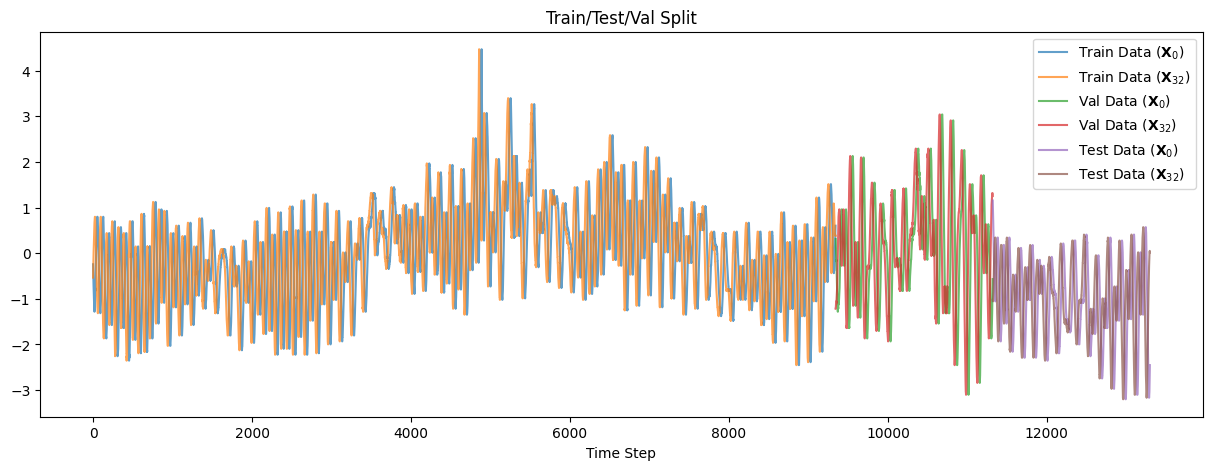

In [9]:
scaler, X_train, y_train, X_val, y_val, X_test, y_test = get_data_tensors(data_path, window_size=WINDOW_SIZE)
plot_data(X_train, X_val, X_test, WINDOW_SIZE)

torch.Size([13296])


C:\Users\Luis\Documents\ML-AI-Projects\custom-lstm\custom_lstm\utils.py:146: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  ts = torch.tensor(time_series, dtype=torch.float32)


<Figure size 1500x500 with 0 Axes>

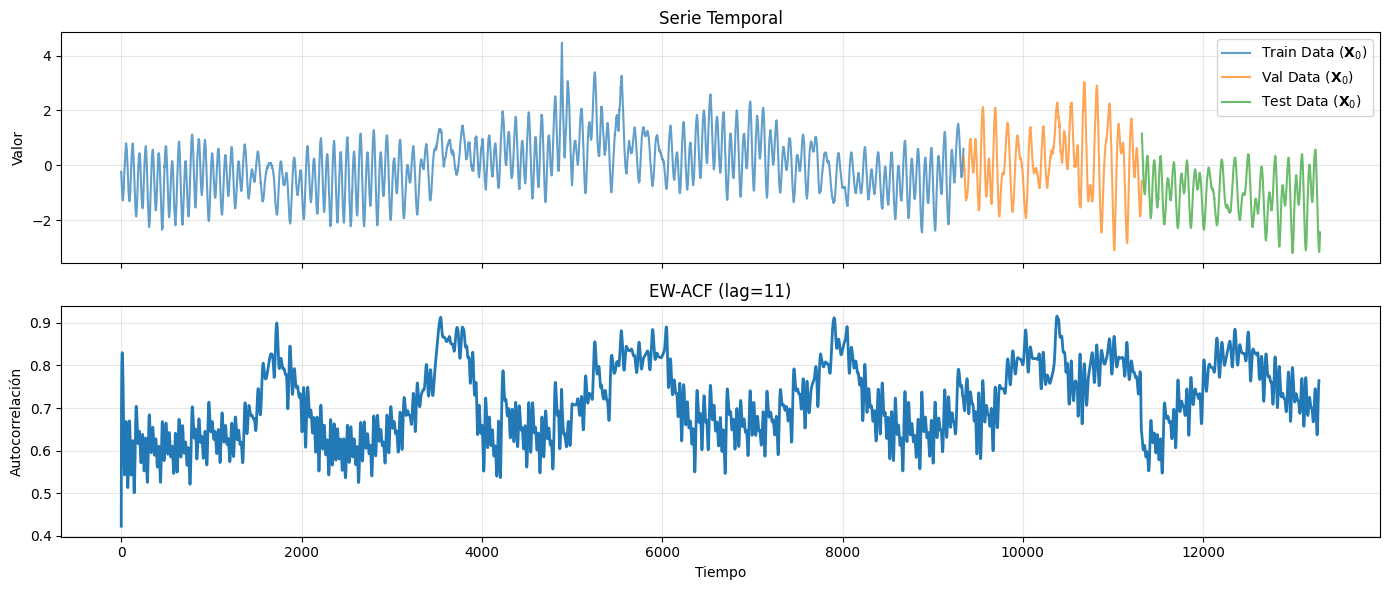

In [10]:
def plot_data_acf(train: torch.Tensor, val: torch.Tensor, test: torch.Tensor):

    plt.figure(figsize=(15, 5))
    train_len = train.squeeze().shape[0]
    val_len = val.squeeze().shape[0]
    test_len = test.squeeze().shape[0]

    train_offset = np.array(list(range(0, train_len)))
    val_offset = np.array(list(range(train_len + 1, train_len + val_len + 1)))
    test_offset = np.array(list(range(train_len + val_len + 1, train_len + val_len + test_len + 1)))

    fig, axs = plt.subplots(2, 1, figsize=(14, 6), sharex=True, gridspec_kw={"height_ratios": [2, 2]})
    axs[0].plot(train_offset, train.squeeze()[:, 0], label=r"Train Data $(\mathbf{X}_0)$", alpha=0.7)
    axs[0].plot(val_offset, val.squeeze()[:, 0], label=r"Val Data $(\mathbf{X}_0)$", alpha=0.7)
    axs[0].plot(test_offset, test.squeeze()[:, 0], label=r"Test Data $(\mathbf{X}_0)$", alpha=0.7)
    axs[0].set_title("Serie Temporal")
    axs[0].set_ylabel("Valor")
    axs[0].grid(alpha=0.3)
    axs[0].legend()

    time_series = torch.concat((train.squeeze().detach().clone()[:, 0], val.squeeze().detach().clone()[:, 0], test.squeeze().detach().clone()[:, 0]), 0)
    print(time_series.shape)
    auto_corr = ew_acf(time_series=time_series, lag=11, lambda_=0.99)
    axs[1].plot(auto_corr, alpha=0.99, linewidth=2)
    axs[1].set_title("EW-ACF (lag=11)")
    axs[1].set_xlabel("Tiempo")
    axs[1].set_ylabel("Autocorrelación")
    axs[1].grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


plot_data_acf(X_train, X_val, X_test)

### 1. Windowed Architecture Experiment MSELoss

Running the model with Windowed LSTM Architecture and MSE loss.


In [15]:
config_mse = {
    "architecture": ArchitectureType.LSTM_VANILLA_WINDOWED,
    "data_mode": DataMode.WINDOWED,
    "loss_type": LossType.MSE,
    "model_kwargs": {"input_size": WINDOW_SIZE, "hidden_size": HIDDEN_SIZE, "output_size": 1},
    "window_size": WINDOW_SIZE,
    "epochs": EPOCHS,
    "lr": LEARNING_RATE,
    "bptt_steps": BPTT_STEPS,
}

results_mse, config_mse_obj = run_lstm_experiment(data_path=data_path, config_kwargs=config_mse, run_name="LSTM_Custom_Windowed_MSE")


Loading data from C:/Users/Luis/Documents/ML-AI-Projects/custom-lstm/data/preprocessed/aqua_alta.csv...
Building ArchitectureType.LSTM_VANILLA_WINDOWED...
Number of parameters: 24897
Model and tensors are running on: cpu
────────────────────────────────────────────────────────────
  Experiment Pipeline Summary
────────────────────────────────────────────────────────────
  Architecture:    ArchitectureType.LSTM_VANILLA_WINDOWED
  Data mode:       DataMode.WINDOWED (input_size=window_size=32)
  Loss:            LossType.MSE
  Trainer:         TrainerStrategyType.TBPTT
  BPTT steps:      50
  Dataset:         aqua_alta (C:/Users/Luis/Documents/ML-AI-Projects/custom-lstm/data/preprocessed/aqua_alta.csv)
  Experiment:      Notebook_Presentation
────────────────────────────────────────────────────────────
Epoch   1/200  |  Train MSE: 0.15286  |  Val MSE: 0.05012
Epoch  10/200  |  Train MSE: 0.00243  |  Val MSE: 0.00569
Epoch  20/200  |  Train MSE: 0.00153  |  Val MSE: 0.00257
Epoch  30/200  

2026/07/01 19:44:46 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytorch model using the safe graph model format.
2026/07/01 19:44:46 WARNING mlflow.utils.requirements_utils: Found torch version (2.8.0+cu129) contains a local version label (+cu129). MLflow logged a pip requirement for this package as 'torch==2.8.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.
2026/07/01 19:44:57 WARNING mlflow.utils.requirements_utils: Found torch version (2.8.0+cu129) contains a local version label (+cu129). MLflow logged a pip requirement for this package as 'torch==2.8.0' without the local version label to make it


Training complete! Best Val Loss: 0.001089
Model logged to MLflow Run ID: 2c9fe76dbf444505a297960448963e74


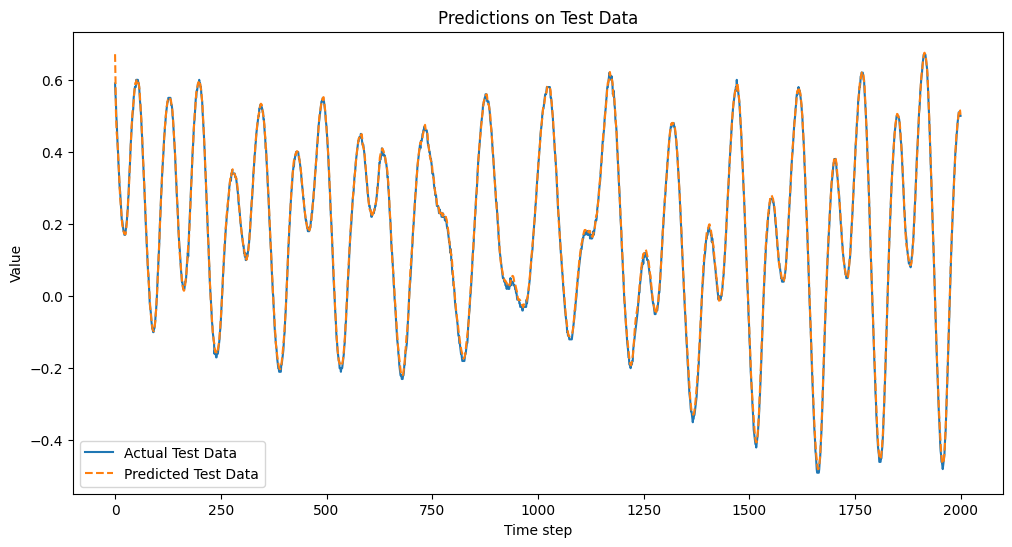


Starting Stateless Experiment: 1000 Warm-up + 500 Generation...


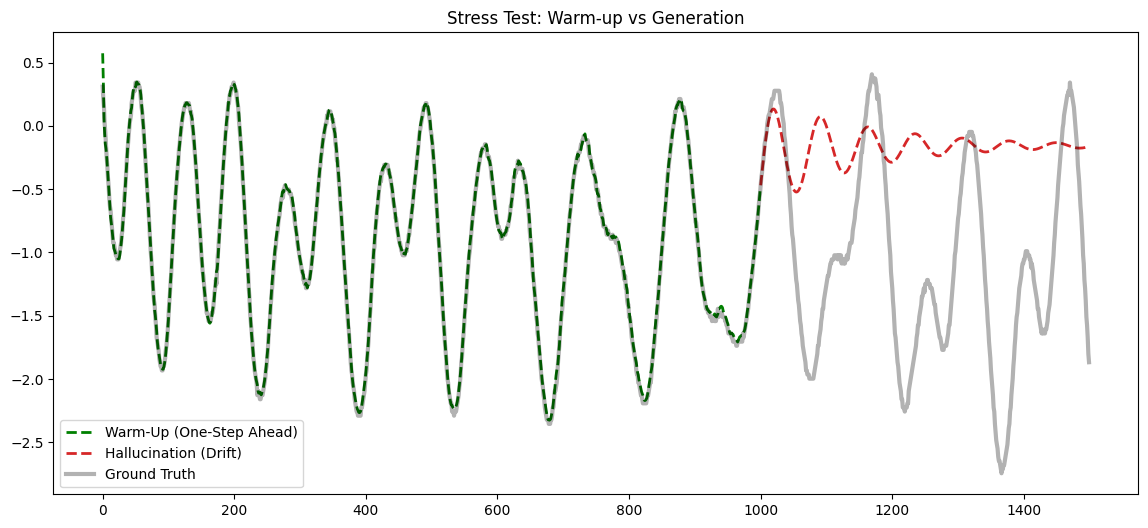

In [31]:
model_mse = results_mse["model"].to(device)

y_pred_mse, telemetry_mse = test_model(model_mse, X_test.to(device), y_test.to(device), scaler)
run_stress_test(model_mse, X_test.to(device), y_test.to(device), device)


### 2. Windowed Architecture Experiment

Running the model with Windowed LSTM Architecture and EW-ACF Broadcast loss.


In [27]:
config_ewacf = {
    "architecture": ArchitectureType.LSTM_CUSTOM_WINDOWED,
    "data_mode": DataMode.WINDOWED,
    "loss_type": LossType.EWACF_BROADCAST,
    "model_kwargs": {"input_size": WINDOW_SIZE, "hidden_size": HIDDEN_SIZE, "output_size": 1},
    "window_size": WINDOW_SIZE,
    "epochs": EPOCHS,
    "lr": LEARNING_RATE,
    "bptt_steps": BPTT_STEPS,
    "ewacf_alpha": 0.01,
    "ewacf_lambda": 0.99,
    "ewacf_lag": 11,
    "ewacf_threshold": 0.3,
}

results_ewacf, config_ewacf_obj = run_lstm_experiment(data_path=data_path, config_kwargs=config_ewacf, run_name="LSTM_Custom_Windowed_EWACF")


Loading data from C:/Users/Luis/Documents/ML-AI-Projects/custom-lstm/data/preprocessed/aqua_alta.csv...
Building ArchitectureType.LSTM_CUSTOM_WINDOWED...
Number of parameters: 71297
Model and tensors are running on: cpu
────────────────────────────────────────────────────────────
  Experiment Pipeline Summary
────────────────────────────────────────────────────────────
  Architecture:    ArchitectureType.LSTM_CUSTOM_WINDOWED
  Data mode:       DataMode.WINDOWED (input_size=window_size=10)
  Loss:            LossType.EWACF_BROADCAST (α=0.01, λ=0.99, lag=11, θ=0.3)
  Trainer:         TrainerStrategyType.EWACF_TBPTT
  BPTT steps:      50
  Effective lag:   11 (enforced >= window_size=10)
  Dataset:         aqua_alta (C:/Users/Luis/Documents/ML-AI-Projects/custom-lstm/data/preprocessed/aqua_alta.csv)
  Experiment:      Notebook_Presentation
────────────────────────────────────────────────────────────
Epoch   1/200  |  Train MSE: 0.05908  |  Val MSE: 0.01478
Epoch  10/200  |  Train MSE: 0.0

2026/05/07 20:36:19 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytorch model using the safe graph model format.
2026/05/07 20:36:19 WARNING mlflow.utils.requirements_utils: Found torch version (2.8.0+cu129) contains a local version label (+cu129). MLflow logged a pip requirement for this package as 'torch==2.8.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.
2026/05/07 20:36:29 WARNING mlflow.utils.requirements_utils: Found torch version (2.8.0+cu129) contains a local version label (+cu129). MLflow logged a pip requirement for this package as 'torch==2.8.0' without the local version label to make it


Training complete! Best Val Loss: 0.000860
Model logged to MLflow Run ID: a58168ddd64b46078a40787862019f02


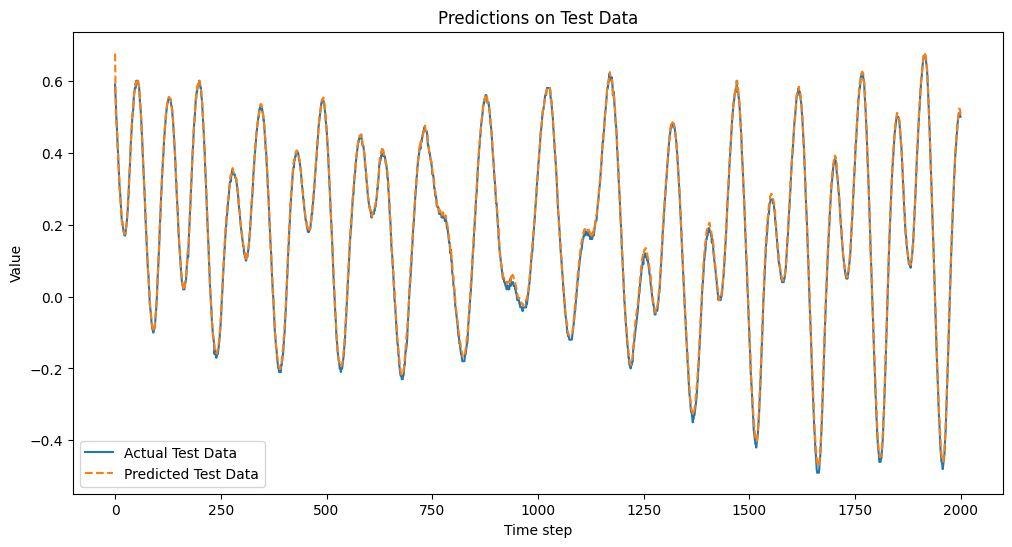


Starting Stateless Experiment: 1000 Warm-up + 500 Generation...


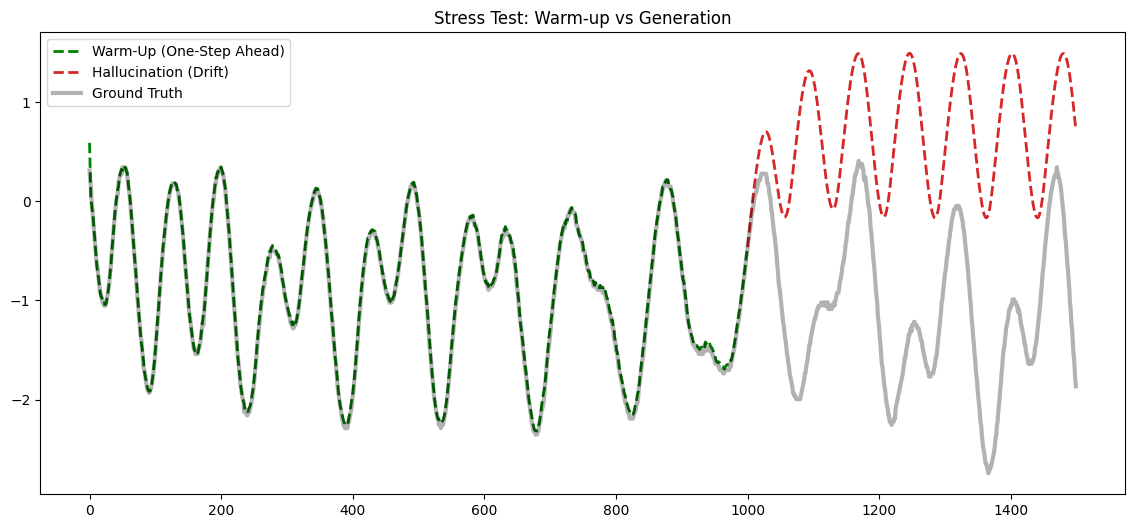

In [28]:
model_ewacf = results_ewacf["model"].to(device)

y_pred_ewacf, telemetry_ewacf = test_model(model_ewacf, X_test.to(device), y_test.to(device), scaler)
run_stress_test(model_ewacf, X_test.to(device), y_test.to(device), device)


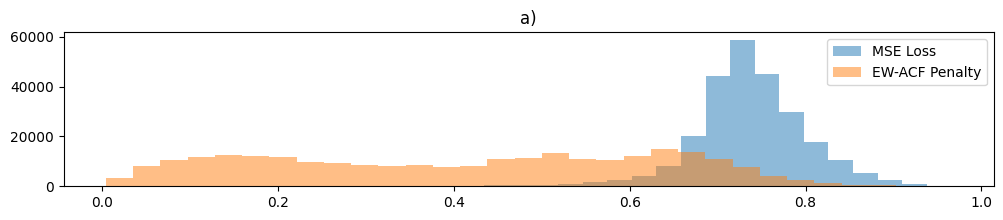

In [36]:
fg_ewacf = telemetry_ewacf.forget_gates.detach().cpu().flatten().numpy()
fg_mse = telemetry_mse.forget_gates.detach().cpu().flatten().numpy()
plt.figure(figsize=(12, 2))
plt.hist(fg_mse, bins=30, alpha=0.5, label="MSE Loss")
plt.hist(fg_ewacf, bins=30, alpha=0.5, label="EW-ACF Penalty")
plt.title("a)")
plt.legend()
plt.show()